# **Imports**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# ------------------------------------------
# desabilita warnings
# ------------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ------------------------------------------
# bibliotecas principais
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv('/content/drive/Shareddrives/grupo4-rappi-hour/bases-rappi/df-oficial.csv')

In [6]:
df = df.drop(columns = ['Unnamed: 0'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157470 entries, 0 to 157469
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   IS_ACTIVE                   157470 non-null  int64  
 1   AUTO_ACEITE                 157470 non-null  int64  
 2   COOKING_TIME_MEDIO          157470 non-null  float64
 3   ITENS_MEDIO                 157470 non-null  float64
 4   DISTANCE_TO_USER            157470 non-null  float64
 5   CANCELS_OPS_RT              157470 non-null  float64
 6   ACCEPTANCE_RATE             157470 non-null  float64
 7   PUNISHMENT_MINUTES          157470 non-null  float64
 8   TEMPORARY_BLOCKS            157470 non-null  float64
 9   WARNINGS                    157470 non-null  float64
 10  ORDERS_PER_HOURS_CONNECTED  157470 non-null  float64
 11  age-1st-qtile               157470 non-null  int64  
 12  age-2nd-qtile               157470 non-null  int64  
 13  age-3rd-qtile 

# Original database


## Features / Target


In [8]:
x = df.drop(columns="IS_ACTIVE") # features
y = df["IS_ACTIVE"] # target

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 1)

In [10]:
from sklearn.preprocessing import MinMaxScaler

# instaciando o objeto scaler
scaler = MinMaxScaler()

# fit + transform no conjunto de treino
# utiliza apenas o transform : fit exclusivo no conjunto de treino
x_train[list(x_train.columns)] = scaler.fit_transform(x_train[list(x_train.columns)])

# scaler no conjunto de teste
x_test[list(x_test.columns)] = scaler.transform(x_test[list(x_test.columns)])

In [11]:
y_train.squeeze()

19778     2
96599     2
58231     2
11258     2
67121     2
         ..
73349     2
109259    2
50057     2
5192      1
128037    2
Name: IS_ACTIVE, Length: 110229, dtype: int64

In [12]:
y_true = y_test

## Random Forest


In [13]:
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [14]:
parameters_gs = {'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': [6, 8],
              'class_weight': ['balanced', 'balanced_subsample'],
              'min_samples_leaf': [2, 4]}

parameters_rs = {'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': [4, 5, 6, 7, 8, 9],
              'class_weight': ['balanced', 'balanced_subsample'],
              'min_samples_leaf': [1, 2, 3, 4, 5, 6]}

### grid search

In [15]:
ranfor_grid_search = GridSearchCV(estimator = RandomForestClassifier(), param_grid=parameters_gs)
ranfor_grid_search.fit(x_train, y_train.squeeze())

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [6, 8], 'min_samples_leaf': [2, 4]})

In [16]:
print(ranfor_grid_search.best_score_)
print(ranfor_grid_search.best_params_)

0.8208910275175267
{'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 2}


In [17]:
ranfor_gs_best = ranfor_grid_search.best_estimator_
ranfor_gs_best

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       min_samples_leaf=2)

In [ ]:
y_pred_ranfor_gs = ranfor_gs_best.predict(x_test)

In [23]:
cm_ranfor_gs = confusion_matrix(y_true, y_pred_ranfor_gs, normalize = 'true')
cm_ranfor_gs

array([[0.99334925, 0.00221692, 0.00443383],
       [0.00246674, 0.6535107 , 0.34402255],
       [0.00602811, 0.14883767, 0.84513422]])

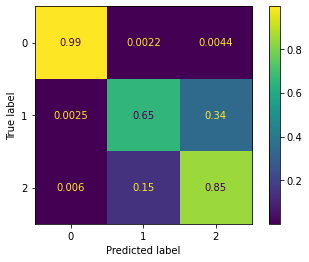

In [24]:
# versão visual mais bonita da matriz
disp_ranfor_gs = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor_gs, 
                              display_labels=ranfor_gs_best.classes_)

disp_ranfor_gs.plot()
plt.show()

In [25]:
print(classification_report(y_test, y_pred_ranfor_gs))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5864
           1       0.62      0.65      0.64     11351
           2       0.87      0.85      0.86     30026

    accuracy                           0.82     47241
   macro avg       0.82      0.83      0.82     47241
weighted avg       0.82      0.82      0.82     47241



### random search

In [26]:
ranfor_random_search = RandomizedSearchCV(estimator = RandomForestClassifier(), param_distributions=parameters_rs)
ranfor_random_search.fit(x_train, y_train.squeeze())

RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [4, 5, 6, 7, 8, 9],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6]})

In [27]:
print(ranfor_random_search.best_score_)
print(ranfor_random_search.best_params_)

0.8209998866881916
{'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}


In [28]:
ranfor_rs_best = ranfor_random_search.best_estimator_
ranfor_rs_best

RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy',
                       max_depth=8, min_samples_leaf=2)

In [30]:
y_pred_ranfor_rs = ranfor_rs_best.predict(x_test)

In [31]:
cm_ranfor_rs = confusion_matrix(y_true, y_pred_ranfor_rs, normalize = 'true')
cm_ranfor_rs

array([[0.99351978, 0.00187585, 0.00460437],
       [0.00281913, 0.65307021, 0.34411065],
       [0.00676081, 0.14940385, 0.84383534]])

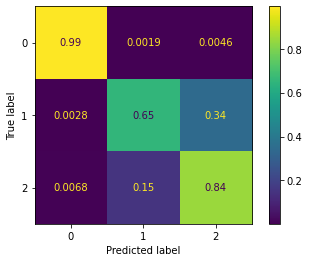

In [32]:
# versão visual mais bonita da matriz
disp_ranfor_rs = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor_rs, 
                              display_labels=ranfor_rs_best.classes_)

disp_ranfor_rs.plot()
plt.show()

In [33]:
print(classification_report(y_test, y_pred_ranfor_rs))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5864
           1       0.62      0.65      0.64     11351
           2       0.87      0.84      0.85     30026

    accuracy                           0.82     47241
   macro avg       0.82      0.83      0.82     47241
weighted avg       0.82      0.82      0.82     47241



# **Cluster Resample**

In [34]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=13)
x_resampled, y_resampled = rus.fit_resample(x, y)

In [35]:
x_train_resampled, x_test_resampled, y_train_resampled, y_test_resampled = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 8)

In [36]:
# Instaciando o objeto scaler
scaler = MinMaxScaler()

# Fit + transform no conjunto de treino
# Utilizando explicitamente as colunas de ambos os lados força que o
# resultado da normalização ainda seja o dataframe (muito mais facil de manipular) e não um numpy array
x_train_resampled[list(x_train_resampled.columns)] = scaler.fit_transform(x_train_resampled[list(x_train_resampled.columns)])

# Agora utilizando o scaler no conjunto de teste
# Utilizar apenas o transform, pois fit é só no conjunto de treino,]
# o conjunto de teste é utilizado para medir a capacidade de generalização do modelo no mundo real (dados não vistos)
# então faz sentido que a mesma normalização treinada e submetida ao conjunto de treino seja apenas aplicada no de teste
x_test_resampled[list(x_test_resampled.columns)] = scaler.transform(x_test_resampled[list(x_test_resampled.columns)])

In [37]:
y_train_resampled.squeeze()

46267     2
141493    0
126779    2
146212    0
62926     2
         ..
141448    0
62426     1
149489    0
25940     1
70083     2
Name: IS_ACTIVE, Length: 110229, dtype: int64

In [38]:
y_true_resampled = y_test_resampled

## Random Forest


### grid search

In [39]:
ranfor_resampled_grid_search = GridSearchCV(estimator = RandomForestClassifier(), param_grid=parameters_gs)
ranfor_resampled_grid_search.fit(x_train_resampled, y_train_resampled.squeeze())

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [6, 8], 'min_samples_leaf': [2, 4]})

In [40]:
print(ranfor_resampled_grid_search.best_score_)
print(ranfor_resampled_grid_search.best_params_)

0.8214988660485909
{'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2}


In [41]:
ranfor_resampled_gs_best = ranfor_grid_search.best_estimator_
ranfor_resampled_gs_best

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       min_samples_leaf=2)

In [42]:
y_pred_ranfor_resampled_gs = ranfor_resampled_gs_best.predict(x_test_resampled)

In [43]:
cm_ranfor_resampled_gs = confusion_matrix(y_true_resampled, y_pred_ranfor_resampled_gs, normalize = 'true')
cm_ranfor_resampled_gs

array([[0.99301554, 0.00279378, 0.00419068],
       [0.00219896, 0.64499956, 0.35280148],
       [0.00630287, 0.13375352, 0.85994361]])

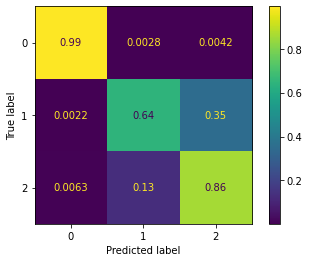

In [44]:
# versão visual mais bonita da matriz
disp_ranfor_resampled_gs = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor_resampled_gs, 
                              display_labels=ranfor_resampled_gs_best.classes_)

disp_ranfor_resampled_gs.plot()
plt.show()

In [45]:
print(classification_report(y_test_resampled, y_pred_ranfor_resampled_gs))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5727
           1       0.64      0.64      0.64     11369
           2       0.87      0.86      0.86     30145

    accuracy                           0.82     47241
   macro avg       0.82      0.83      0.83     47241
weighted avg       0.82      0.82      0.82     47241



### random search

In [46]:
ranfor_resampled_random_search = RandomizedSearchCV(estimator = RandomForestClassifier(), param_distributions=parameters_rs)
ranfor_resampled_random_search.fit(x_train_resampled, y_train_resampled.squeeze())

RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [4, 5, 6, 7, 8, 9],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6]})

In [47]:
print(ranfor_resampled_random_search.best_score_)
print(ranfor_resampled_random_search.best_params_)

0.8255268557730391
{'min_samples_leaf': 5, 'max_depth': 9, 'criterion': 'gini', 'class_weight': 'balanced'}


In [48]:
ranfor_resampled_rs_best = ranfor_resampled_random_search.best_estimator_
ranfor_resampled_rs_best

RandomForestClassifier(class_weight='balanced', max_depth=9, min_samples_leaf=5)

In [49]:
y_pred_ranfor_resampled_rs = ranfor_resampled_rs_best.predict(x_test_resampled)

In [50]:
cm_ranfor_resampled_rs = confusion_matrix(y_true_resampled, y_pred_ranfor_resampled_rs, normalize = 'true')
cm_ranfor_resampled_rs

array([[0.99301554, 0.00279378, 0.00419068],
       [0.00175917, 0.67789603, 0.3203448 ],
       [0.00232211, 0.15249627, 0.84518162]])

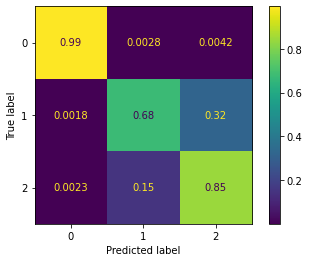

In [51]:
# versão visual mais bonita da matriz
disp_ranfor_resampled_rs = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor_resampled_rs, 
                              display_labels=ranfor_resampled_rs_best.classes_)

disp_ranfor_resampled_rs.plot()
plt.show()

In [52]:
print(classification_report(y_test_resampled, y_pred_ranfor_resampled_rs))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5727
           1       0.63      0.68      0.65     11369
           2       0.87      0.85      0.86     30145

    accuracy                           0.82     47241
   macro avg       0.83      0.84      0.83     47241
weighted avg       0.83      0.82      0.82     47241

